# Exploración Dataset HAM10000 (Human Against Machine with 10000 training images)

Conjunto de datos diseñado para el entrenamiento y evaluación de modelos de aprendizaje automático en el diagnóstico de enfermedades de la piel a partir de imágenes dermatoscópicas [1]. El conjunto de datos contiene 10,015 imágenes de lesiones cutáneas clasificadas en siete categorías distintas, que abarcan enfermedades benignas y malignas. Cada imagen ha sido recopilada de pacientes de diferentes grupos demográficos y proviene de diversas fuentes, asegurando una mayor representatividad y variabilidad en la muestra.

| **Enfermedad** | **Descripción** | **Código** |
|---|---|---|
| **Actinic keratoses y carcinoma de células escamosas** | Tipo de cáncer de piel | akiec |
| **Nevus melanocítico** | Lesión benigna común | nv |
| **Melanoma** | Tipo de cáncer de piel agresivo | mel |
| **Lesiones benignas de queratosis** | Incluyen lentigo solar y queratosis seborreica | bkl |
| **Dermatofibroma** | Lesión benigna del tejido fibroso | df |
| **Vasculares** | Lesiones vasculares como hemangiomas | vasc |
| **Lesión de células basales** | Un tipo de cáncer de piel menos agresivo que el melanoma | bcc |

#1. Descarga del dataset y exploración de los datos
URL https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

Contenido del Dataset

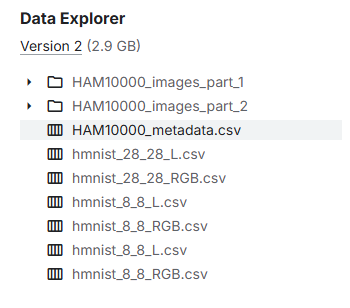



In [51]:
#Imports
import os
import kagglehub
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.utils import plot_model

In [2]:
#Ruta del dataset
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Ruta de archivos:", path)

100%|██████████| 5.20G/5.20G [00:27<00:00, 204MB/s]

Extracting files...


Ruta de archivos: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [3]:
#Carpetas en la ruta que se descarga
!ls {path}/HAM10000_images_part_2 | head -n 5

ISIC_0029306.jpg
ISIC_0029307.jpg
ISIC_0029308.jpg
ISIC_0029309.jpg
ISIC_0029310.jpg


In [4]:
#Copia del dataset a Content
!cp -r {path}/* ./
#!rm -rf ./*

In [5]:
#Carpetas dentro de content
!ls ./HAM10000_images_part_1/ | head -n 5
#!ls ./HAM10000_images_part_2/ | head -n 5

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg


In [6]:
#Ruta dentro de la carpeta content
#path_content = "skin-cancer-mnist-ham10000"
path_content = ""

#Ruta de los archivo csv
data_csv = os.path.join(path_content, "HAM10000_metadata.csv")
print("Ruta de archivos data csv:", data_csv)

hmnist_28_csv = os.path.join(path_content, "hmnist_28_28_RGB.csv")
print("Ruta de archivos hmnist_28_csv:", hmnist_28_csv)

#Ruta de las imagenes
folder_img_1 = "HAM10000_images_part_1"
images_dir_1 = os.path.join(path_content, folder_img_1)
print("Ruta de imagenes parte 1:", images_dir_1)

folder_img_2 = "HAM10000_images_part_2"
images_dir_2 = os.path.join(path_content, folder_img_2)
print("Ruta de imagenes parte 2:", images_dir_2)

#Directorio para unificar las imagenes.
folder_img_all = "HAM10000_images_all"
images_dir_all = os.path.join(path_content, folder_img_all)
print("Ruta de imagenes completo", images_dir_all)

Ruta de archivos data csv: HAM10000_metadata.csv
Ruta de archivos hmnist_28_csv: hmnist_28_28_RGB.csv
Ruta de imagenes parte 1: HAM10000_images_part_1
Ruta de imagenes parte 2: HAM10000_images_part_2
Ruta de imagenes completo HAM10000_images_all


In [7]:
#Exploración de los dataset (CSV)
raw_df = pd.read_csv(data_csv, on_bad_lines="skip")
raw_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
#Explicación del campo dx_type
raw_df['dx_type'].value_counts()

#histo (5340) — confirmado por histopatología (biopsia analizada en laboratorio). Es el método más fiable.
#follow_up (3704) — confirmado por seguimiento clínico a lo largo del tiempo, observando la evolución de la lesión.
#consensus (902) — diagnóstico por consenso de expertos (varios dermatólogos coinciden en el diagnóstico).
#confocal (69) — diagnosticado mediante microscopía confocal in vivo, una técnica de imagen no invasiva.


,count
dx_type,
histo,5340
follow_up,3704
consensus,902
confocal,69


In [9]:
#Se crea el directorio, donde se consolidan todas las imagenes.
!mkdir ./{folder_img_all}/

In [10]:
#Se mueven las imagenes a un solo directorio
!mv ./{folder_img_1}/* ./{folder_img_all}/
!mv ./{folder_img_2}/* ./{folder_img_all}/

In [11]:
#Se validan los directorios
!ls ./{folder_img_1}/ | head -n 5
!ls ./{folder_img_2}/ | head -n 5

In [13]:
!ls ./{folder_img_all}/ | head -n 5

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg


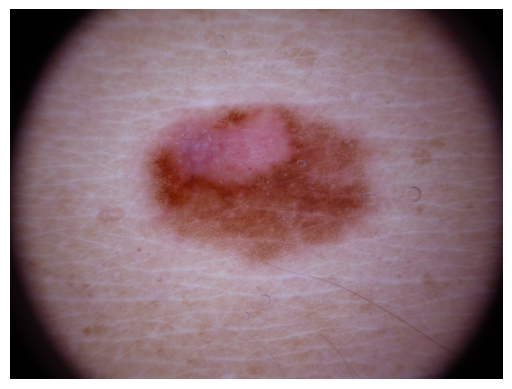

(450, 600, 3)
lesion_id        HAM_0005711
image_id        ISIC_0033779
dx                       mel
dx_type                histo
age                     35.0
sex                     male
localization            back
Name: 1642, dtype: object


In [14]:
#Se muestra una imagen de ejemplo
idx = 1642
row = raw_df.iloc[idx]
image_path = f"./{folder_img_all}/{row["image_id"]}.jpg"
image = cv2.imread(image_path)[:, :, ::-1]

plt.imshow(image)
plt.axis("off")
plt.show()

print(image.shape)
print(row)


#2. Preparación del data set

In [15]:
#Preparación del data set
#df = raw_df.drop_duplicates(subset=["lesion_id"]).copy()
df = raw_df.copy()
df['id'] = df['lesion_id'].str.replace('HAM_', '', regex=False)
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df = df.dropna(subset=["id", "dx"]).copy()

df["dx"] = df["dx"].astype(str).str.strip()
df["dx_type"] = df["dx_type"].astype(str).str.strip()
df["sex"] = df["sex"].astype(str).str.strip()
df["localization"] = df["localization"].astype(str).str.strip()
df["image_path"] = df["image_id"].astype(str).map(lambda x: os.path.join(images_dir_all, f"{x}.jpg"))
df = df[df["image_path"].map(os.path.exists)].reset_index(drop=True)

In [16]:
#Revision del DF
raw_df.info()
df.info()
df.head()
df.isnull().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 

,0
lesion_id,False
image_id,False
dx,False
dx_type,False
age,True
sex,False
localization,False
id,False
image_path,False


In [22]:
#Definición de variables categoricas y numericas
categorical_cols = ["dx_type", "sex", "localization"]
numeric_cols = ["age"]
tabular_cols = categorical_cols + numeric_cols

class_names = sorted(df["dx"].unique().tolist())
class_to_index = {name: i for i, name in enumerate(class_names)}
df["label"] = df["dx"].map(class_to_index).astype(np.int32)

In [23]:
df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,id,image_path,label
2508,HAM_0000393,ISIC_0031943,bcc,histo,40.0,female,abdomen,393,HAM10000_images_all/ISIC_0031943.jpg,1
6659,HAM_0000894,ISIC_0030478,nv,follow_up,45.0,female,upper extremity,894,HAM10000_images_all/ISIC_0030478.jpg,5
2810,HAM_0006386,ISIC_0029035,bcc,histo,70.0,male,face,6386,HAM10000_images_all/ISIC_0029035.jpg,1
328,HAM_0007296,ISIC_0027068,bkl,histo,65.0,female,upper extremity,7296,HAM10000_images_all/ISIC_0027068.jpg,2
7984,HAM_0001547,ISIC_0034297,nv,histo,25.0,male,lower extremity,1547,HAM10000_images_all/ISIC_0034297.jpg,5


In [26]:
#Separación de los dataframe para training, validation y test.
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
)

In [36]:
#Se preprocesan los datos de las columnas, imputando la media para las columnas de tipo numerica
# y Unknow para las categoricas.
tabular_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_cols,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
    ]
)

In [38]:
#Dataset de valores
X_train_tab = tabular_preprocessor.fit_transform(train_df[tabular_cols]).astype("float32")
X_val_tab = tabular_preprocessor.transform(val_df[tabular_cols]).astype("float32")
X_test_tab = tabular_preprocessor.transform(test_df[tabular_cols]).astype("float32")

In [39]:
#Dataset de imagenes
train_paths = train_df["image_path"].astype(str).values
val_paths = val_df["image_path"].astype(str).values
test_paths = test_df["image_path"].astype(str).values

In [40]:
#Dataset de resultados
y_train = train_df["label"].values.astype("int32")
y_val = val_df["label"].values.astype("int32")
y_test = test_df["label"].values.astype("int32")

In [41]:
print("Classes:", class_names)
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
print("Tabular feature dimension:", X_train_tab.shape[1])

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train size: 8012
Val size: 1001
Test size: 1002
Tabular feature dimension: 23


#3. Modelos predictivos basicos

## 3.1 Modelo 1D (Tabular)

In [42]:
#Redefino las columnas para el modelo 1D
categorical_cols = ["sex", "localization"]
numeric_cols = ["age"]
tabular_cols = categorical_cols + numeric_cols

epochs = 15
batch_size = 128
learning_rate_frozen = 1e-3

In [43]:
#Se preprocesan los datos de las columnas, imputando la media para las columnas de tipo numerica
# y Unknow para las categoricas.
tabular_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_cols,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
    ]
)

In [44]:
X_train_tab = tabular_preprocessor.fit_transform(train_df[tabular_cols]).astype("float32")
X_val_tab = tabular_preprocessor.transform(val_df[tabular_cols]).astype("float32")
X_test_tab = tabular_preprocessor.transform(test_df[tabular_cols]).astype("float32")

In [45]:
def make_dataset(tabular_array, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((tabular_array, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(labels), reshuffle_each_iteration=True)

    def mapper(tabular, label):
        return {"tabular_input": tabular}, label

    ds = ds.map(mapper)
    ds = ds.batch(batch_size)
    return ds

In [46]:
train_ds = make_dataset(X_train_tab, y_train, training=True)
val_ds = make_dataset(X_val_tab, y_val, training=False)
test_ds = make_dataset(X_test_tab, y_test, training=False)

In [47]:
#Modelo Tabular
tabular_input = tf.keras.Input(shape=(X_train_tab.shape[1],), name="tabular_input")
x_tab = tf.keras.layers.Dense(256, activation="relu")(tabular_input)
x_tab = tf.keras.layers.BatchNormalization()(x_tab)
x_tab = tf.keras.layers.Dropout(0.3)(x_tab)

x_tab = tf.keras.layers.Dense(128, activation="relu")(x_tab)
x_tab = tf.keras.layers.BatchNormalization()(x_tab)
x_tab = tf.keras.layers.Dropout(0.3)(x_tab)

x_tab = tf.keras.layers.Dense(128, activation="relu")(x_tab)
x_tab = tf.keras.layers.BatchNormalization()(x_tab)
x_tab = tf.keras.layers.Dropout(0.3)(x_tab)

x = tf.keras.layers.Dense(128, activation="relu")(x_tab)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(len(class_names), activation="softmax", name="gender_output")(x)

In [59]:
model = tf.keras.Model(inputs=[tabular_input], outputs=output)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 254, 254,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 254, 254,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 254, 254,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 127, 127,  │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 125, 125,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 62, 62,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 60, 60,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 60, 60,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 30, 30,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 19)        │          0 │ -               

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

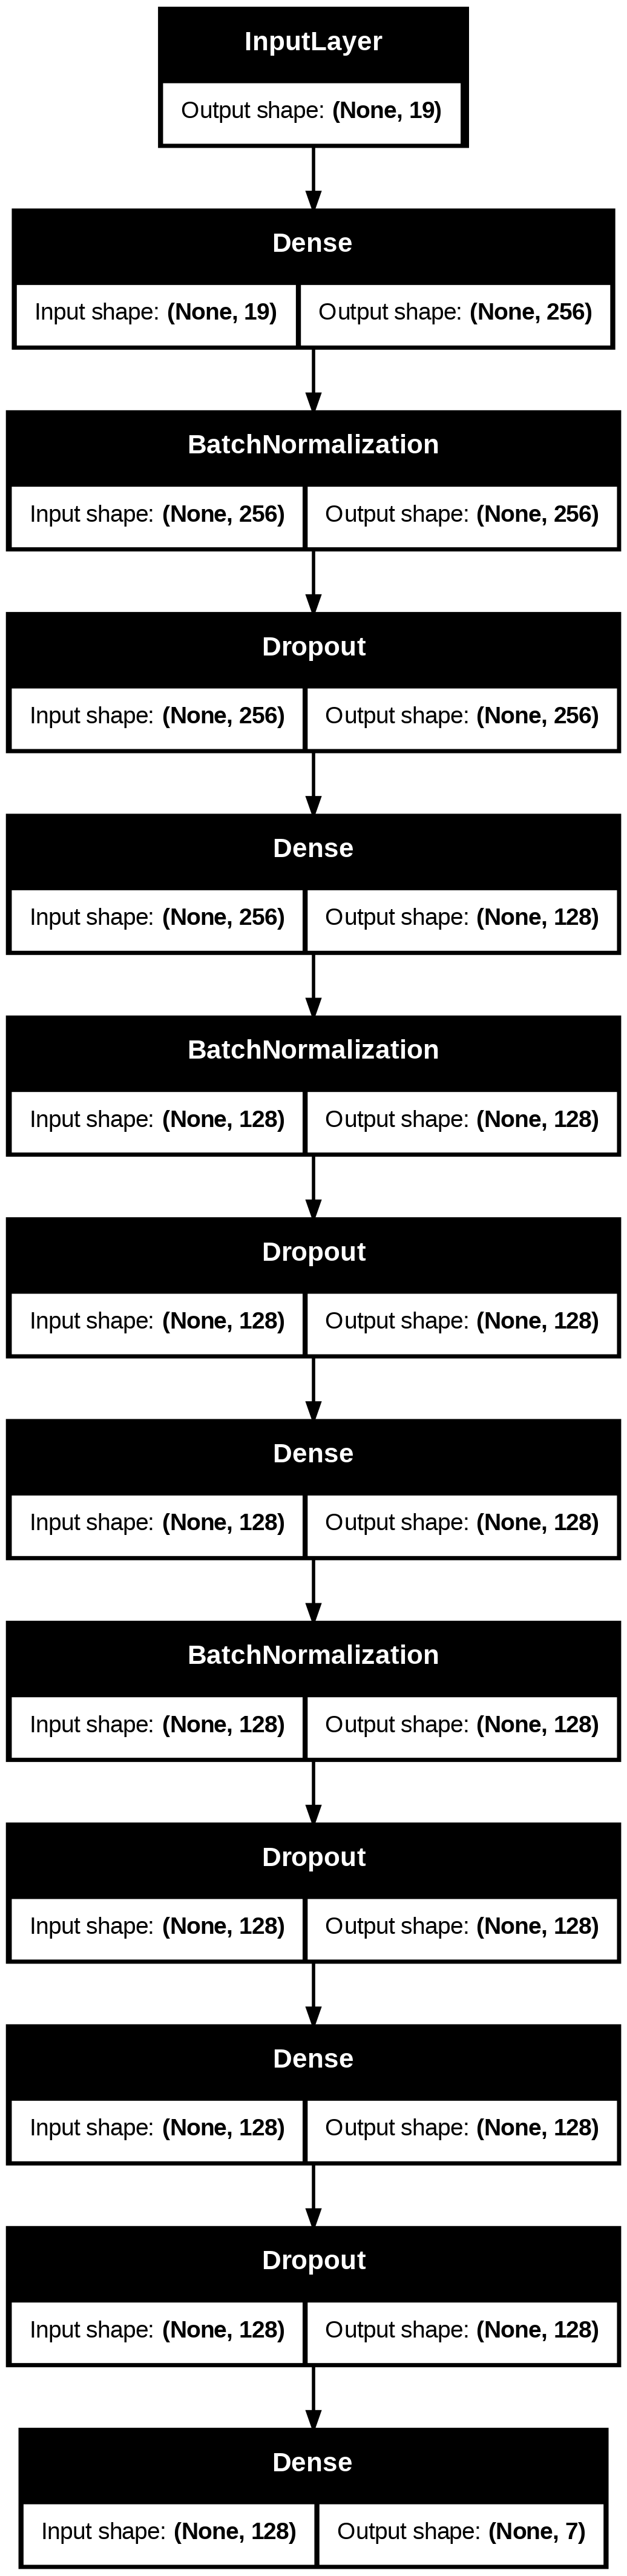

In [52]:
plot_model(model, show_shapes=True)

In [53]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_frozen),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.6112 - loss: 1.2821 - val_accuracy: 0.6693 - val_loss: 1.3001
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6701 - loss: 1.0728 - val_accuracy: 0.6693 - val_loss: 1.0928
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6760 - loss: 1.0077 - val_accuracy: 0.6693 - val_loss: 1.0073
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6776 - loss: 0.9962 - val_accuracy: 0.6733 - val_loss: 0.9725
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6868 - loss: 0.9705 - val_accuracy: 0.6963 - val_loss: 0.9364
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6896 - loss: 0.9662 - val_accuracy: 0.7023 - val_loss: 0.9150
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6878 - loss: 0.9514 - val_accuracy: 0.7003 - val_loss: 0.8946
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6915 - loss: 0.9418 - val_accuracy: 0.7033 - val_los

## 3.2 Modelo 2D (Imágenes)

In [54]:
#Definición de hiperparametros
image_size = (256, 256)
batch_size = 128
epochs = 10
learning_rate_frozen = 1e-3

In [55]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    return image


def make_dataset(image_paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(labels), reshuffle_each_iteration=True)

    def mapper(image_path, label):
        image = load_image(image_path)
        return {"image_input": image}, label

    ds = ds.map(mapper)
    ds = ds.batch(batch_size)
    return ds

In [56]:
train_ds = make_dataset(train_paths, y_train, training=True)
val_ds = make_dataset(val_paths, y_val, training=False)
test_ds = make_dataset(test_paths, y_test, training=False)

In [57]:
#Modelo de Imagenes
image_input = tf.keras.Input(shape=(image_size[0], image_size[1], 3), name="image_input")

x_feat = tf.keras.layers.Conv2D(32, kernel_size=3)(image_input)
x_feat = tf.keras.layers.BatchNormalization()(x_feat)
x_feat = tf.keras.layers.ReLU()(x_feat)
x_feat = tf.keras.layers.MaxPool2D((2, 2))(x_feat)

x_feat = tf.keras.layers.Conv2D(64, kernel_size=3)(x_feat)
x_feat = tf.keras.layers.BatchNormalization()(x_feat)
x_feat = tf.keras.layers.ReLU()(x_feat)
x_feat = tf.keras.layers.MaxPool2D((2, 2))(x_feat)

x_feat = tf.keras.layers.Conv2D(128, kernel_size=3)(x_feat)
x_feat = tf.keras.layers.BatchNormalization()(x_feat)
x_feat = tf.keras.layers.ReLU()(x_feat)
x_feat = tf.keras.layers.MaxPool2D((2, 2))(x_feat)

x_pooled = tf.keras.layers.GlobalAveragePooling2D()(x_feat)
x_pooled = tf.keras.layers.Flatten()(x_pooled)

x = tf.keras.layers.Dense(128, activation="relu")(x_pooled)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(len(class_names), activation="softmax", name="gender_output")(x)

In [60]:
model = tf.keras.Model(inputs=[image_input], outputs=output)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gender_output (Dense)           │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

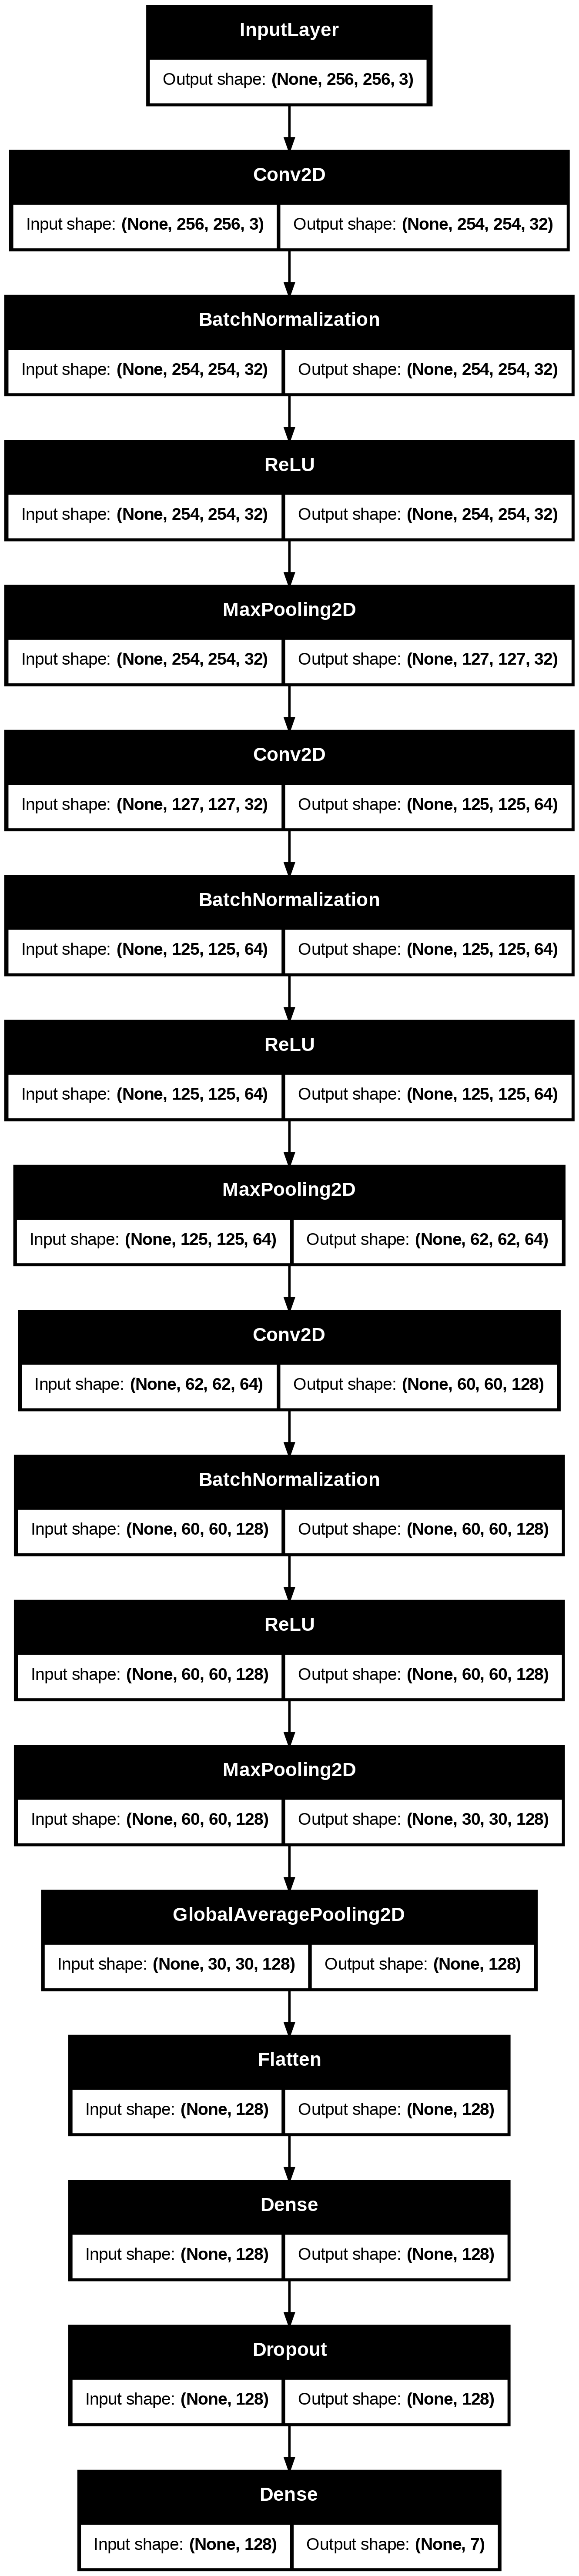

In [61]:
plot_model(model, show_shapes=True)

In [62]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_frozen),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6378 - loss: 1.0327 - val_accuracy: 0.6693 - val_loss: 3.9006
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 693ms/step - accuracy: 0.6777 - loss: 0.8761 - val_accuracy: 0.6673 - val_loss: 1.4708
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 669ms/step - accuracy: 0.6856 - loss: 0.8435 - val_accuracy: 0.6693 - val_loss: 1.2625
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 734ms/step - accuracy: 0.6912 - loss: 0.8268 - val_accuracy: 0.6693 - val_loss: 0.8742
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 654ms/step - accuracy: 0.7049 - loss: 0.7963 - val_accuracy: 0.6234 - val_loss: 0.9035
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 732ms/step - accuracy: 0.7101 - loss: 0.7853 - val_accuracy: 0.6723 - val_loss: 1.2530
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 654ms/step - accuracy: 0.7141 - loss: 0.7648 - val_accuracy: 0.3067 - val_loss: 1.5425
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 652ms/step - accuracy: 0.7184 - loss: 0.7574 - val_accurac

### Validación modelo de imagenes

| Atributo | Valor |
| :--- | :--- |
| **lesion_id** | HAM_0000048 |
| **image_id** | ISIC_0033902 |
| **dx** | mel |
| **dx_type** | histo |
| **age** | 75.0 |
| **sex** | male |
| **localization** | lower extremity |

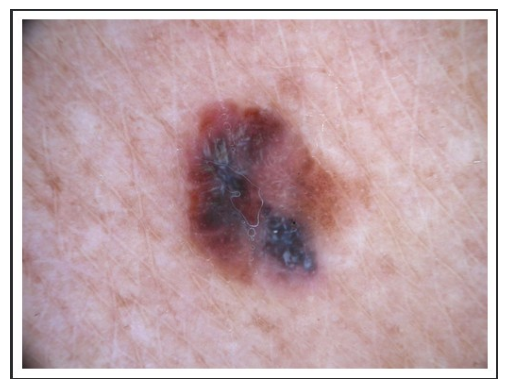

In [63]:
## Validación con una imagen del data set
#Dataframe de Prueba para la predicción
pred_df = pd.DataFrame([{
    "dx_type": "histo",
    "sex": "male",
    "localization": "lower extremity",
    "age": 75,
    "image_path": "image_test.jpg"
}])

image = cv2.imread(pred_df["image_path"][0])
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [64]:
#Transformación de la iamgen
img_predict_tensor = np.expand_dims(load_image(pred_df["image_path"][0]), axis=0)  # 1, 64, 64, 3
#img_predict_tensor.shape

In [65]:
#Predicción del modelo
pred = model.predict([img_predict_tensor])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [66]:
#Resultado
pred_idx = pred.argmax()
pred_class = class_names[pred_idx]

print(f"Soy una imagen de Clase: {pred_class}")

Soy una imagen de Clase: nv


In [67]:
top_indices = np.argsort(pred[0])[::-1]

for i in top_indices:
  print(f"{class_names[i]}: {(pred[0][i]*100)}")

nv: 83.13788604736328
bcc: 6.228035926818848
bkl: 4.302034854888916
mel: 3.1296823024749756
akiec: 1.39480459690094
vasc: 1.1028811931610107
df: 0.7046709060668945
